# Machine Learning Model Building

## Buyer Segmentation using Clustering Algorithms

This notebook performs feature engineering, encoding, scaling and clustering to identify hidden buyer segments.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage

In [2]:
master = pd.read_csv("../data/master_dataset.csv")

In [3]:
master.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,age,client_ref,total_properties,total_investment,average_sale_price,average_floor_area
0,C0001,Individual,Kareem,Liu,1968-11-05,F,USA,California,Home,4,Yes,Website,57,C0001,4,1246764.72,311691.180000,983.885000
1,C0002,Individual,Trystan,Oconnor,1962-11-26,M,USA,California,Home,1,No,Website,63,C0002,5,1841095.93,368219.186000,1187.942000
2,C0003,Individual,Kale,Gay,1959-07-04,M,USA,California,Home,4,Yes,Agency,67,C0003,5,1661457.59,332291.518000,1058.110000
3,C0004,Individual,Russell,Gross,1959-11-25,M,USA,California,Home,5,No,Website,66,C0004,6,1608263.51,268043.918333,937.103333
4,C0005,Company,Marleez,Co,1976-02-28,M,USA,California,Investment,5,No,Website,50,C0005,13,3653385.38,281029.644615,927.296154


In [4]:
master.shape

(2000, 18)

In [5]:
master.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   client_id            2000 non-null   str    
 1   client_type          2000 non-null   str    
 2   first_name           2000 non-null   str    
 3   last_name            2000 non-null   str    
 4   date_of_birth        2000 non-null   str    
 5   gender               2000 non-null   str    
 6   country              2000 non-null   str    
 7   region               2000 non-null   str    
 8   acquisition_purpose  2000 non-null   str    
 9   satisfaction_score   2000 non-null   int64  
 10  loan_applied         2000 non-null   str    
 11  referral_channel     2000 non-null   str    
 12  age                  2000 non-null   int64  
 13  client_ref           2000 non-null   str    
 14  total_properties     2000 non-null   int64  
 15  total_investment     2000 non-null   float64
 16 

## Feature Selection

The clustering model requires both demographic and investment-related variables.

In [6]:
selected_columns = [

    "client_type",

    "gender",

    "country",

    "region",

    "age",

    "acquisition_purpose",

    "loan_applied",

    "referral_channel",

    "satisfaction_score",

    "total_properties",

    "total_investment",

    "average_sale_price",

    "average_floor_area"

]

In [7]:
data = master[selected_columns].copy()

data.head()

,client_type,gender,country,region,age,acquisition_purpose,loan_applied,referral_channel,satisfaction_score,total_properties,total_investment,average_sale_price,average_floor_area
0,Individual,F,USA,California,57,Home,Yes,Website,4,4,1246764.72,311691.180000,983.885000
1,Individual,M,USA,California,63,Home,No,Website,1,5,1841095.93,368219.186000,1187.942000
2,Individual,M,USA,California,67,Home,Yes,Agency,4,5,1661457.59,332291.518000,1058.110000
3,Individual,M,USA,California,66,Home,No,Website,5,6,1608263.51,268043.918333,937.103333
4,Company,M,USA,California,50,Investment,No,Website,5,13,3653385.38,281029.644615,927.296154


In [8]:
data.shape

(2000, 13)

In [9]:
data.isnull().sum()

client_type            0
gender                 0
country                0
region                 0
age                    0
acquisition_purpose    0
loan_applied           0
referral_channel       0
satisfaction_score     0
total_properties       0
total_investment       0
average_sale_price     0
average_floor_area     0
dtype: int64

In [10]:
data.fillna(0, inplace=True)

,client_type,gender,country,region,age,acquisition_purpose,loan_applied,referral_channel,satisfaction_score,total_properties,total_investment,average_sale_price,average_floor_area
0,Individual,F,USA,California,57,Home,Yes,Website,4,4,1246764.72,311691.180000,983.885000
1,Individual,M,USA,California,63,Home,No,Website,1,5,1841095.93,368219.186000,1187.942000
2,Individual,M,USA,California,67,Home,Yes,Agency,4,5,1661457.59,332291.518000,1058.110000
3,Individual,M,USA,California,66,Home,No,Website,5,6,1608263.51,268043.918333,937.103333
4,Company,M,USA,California,50,Investment,No,Website,5,13,3653385.38,281029.644615,927.296154
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,Individual,F,USA,Nevada,34,Home,Yes,Website,1,4,1151831.48,287957.870000,1027.325000
1996,Individual,M,USA,Arizona,83,Home,Yes,Website,4,4,1101825.40,275456.350000,910.420000
1997,Individual,M,USA,Virginia,62,Home,Yes,Website,5,3,1023688.56,341229.520000,1140.400000
1998,Individual,M,USA,Ohio,82,Home,Yes,Client,4,3,838587.38,279529.126667,919.046667


In [11]:
data.isnull().sum()

client_type            0
gender                 0
country                0
region                 0
age                    0
acquisition_purpose    0
loan_applied           0
referral_channel       0
satisfaction_score     0
total_properties       0
total_investment       0
average_sale_price     0
average_floor_area     0
dtype: int64

## Encoding Categorical Variables

Machine learning algorithms cannot process text directly.

Therefore categorical variables are encoded into numerical representations.

In [12]:
categorical = [

    "client_type",

    "gender",

    "country",

    "region",

    "acquisition_purpose",

    "loan_applied",

    "referral_channel"

]

In [13]:
data = pd.get_dummies(

    data,

    columns=categorical,

    drop_first=True

)

In [14]:
data.head()

,age,satisfaction_score,total_properties,total_investment,average_sale_price,average_floor_area,client_type_Individual,gender_M,country_Belgium,country_Canada,...,region_Wales,region_Wallonia,region_Washington,region_Western Australia,region_Wyoming,region_Zealand,acquisition_purpose_Investment,loan_applied_Yes,referral_channel_Client,referral_channel_Website
0,57,4,4,1246764.72,311691.180000,983.885000,True,False,False,False,...,False,False,False,False,False,False,False,True,False,True
1,63,1,5,1841095.93,368219.186000,1187.942000,True,True,False,False,...,False,False,False,False,False,False,False,False,False,True
2,67,4,5,1661457.59,332291.518000,1058.110000,True,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,66,5,6,1608263.51,268043.918333,937.103333,True,True,False,False,...,False,False,False,False,False,False,False,False,False,True
4,50,5,13,3653385.38,281029.644615,927.296154,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True


In [15]:
data.shape

(2000, 77)

## Feature Scaling

Scaling ensures that variables with larger numerical ranges do not dominate clustering.

In [16]:
scaler = StandardScaler()

In [17]:
scaled_data = scaler.fit_transform(data)

In [18]:
scaled_data.shape

(2000, 77)

In [19]:
scaled_data[:5]

array([[ 0.07238436,  0.68708886,  0.41394171, -0.03914021, -0.50784142,
        -0.74405992,  0.23301557, -1.01207287, -0.14823092, -0.21068086,
        -0.08692914, -0.16498899, -0.16972503, -0.14285714, -0.1353881 ,
        -0.22331316,  0.54807857, -0.23891934, -0.0592646 , -0.0776931 ,
        -0.07436678, -0.10050378, -0.08980265, -0.0776931 ,  1.46954335,
        -0.05006262, -0.02236627, -0.2503982 , -0.12129857, -0.08980265,
        -0.16012815, -0.13150665, -0.08980265, -0.0592646 , -0.08692914,
        -0.06723349, -0.02236627, -0.07088812, -0.08692914, -0.0592646 ,
        -0.03875891, -0.27749941, -0.08088589, -0.15847815, -0.04476615,
        -0.04476615, -0.07088812, -0.11020775, -0.05006262, -0.07088812,
        -0.06337243, -0.11020775, -0.06723349, -0.22454436, -0.07088812,
        -0.0592646 , -0.08396038, -0.04476615, -0.07088812, -0.11250879,
        -0.03875891, -0.03875891, -0.06337243, -0.16972503, -0.21325643,
        -0.08088589, -0.18328047, -0.09258979, -0.0

## Part 1 Complete

Dataset prepared successfully for clustering.

Completed Tasks

✔ Feature Selection

✔ Missing Value Handling

✔ Encoding

✔ Standardization

The data is now ready for K-Means clustering.

# K-Means Clustering

K-Means clustering is used to discover hidden buyer segments based on demographic, financial and investment characteristics.

The optimal number of clusters is determined using the Elbow Method and Silhouette Score.

In [20]:
wcss = []

for i in range(2,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

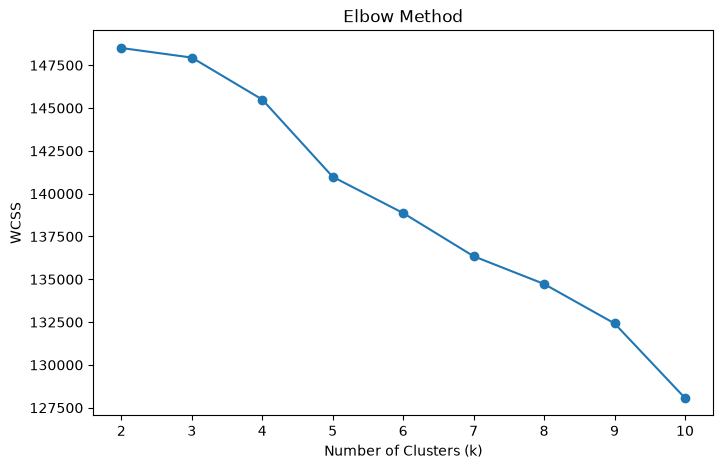

In [21]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

### Business Insight

The elbow point represents the optimal number of buyer segments where additional clusters provide diminishing improvements.

In [22]:
scores = []

for i in range(2,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(scaled_data)

    score = silhouette_score(
        scaled_data,
        labels
    )

    scores.append(score)

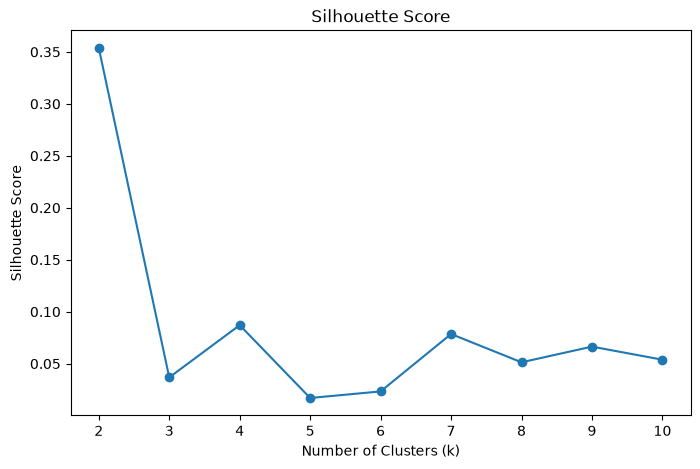

In [23]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    scores,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")

plt.title("Silhouette Score")

plt.show()

### Business Insight

Higher silhouette scores indicate better cluster separation and more meaningful customer segmentation.

In [24]:
best_k = scores.index(max(scores)) + 2

print(best_k)

2


In [25]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(
    scaled_data
)

In [26]:
master["Cluster"] = clusters

In [27]:
master.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,age,client_ref,total_properties,total_investment,average_sale_price,average_floor_area,Cluster
0,C0001,Individual,Kareem,Liu,1968-11-05,F,USA,California,Home,4,Yes,Website,57,C0001,4,1246764.72,311691.180000,983.885000,0
1,C0002,Individual,Trystan,Oconnor,1962-11-26,M,USA,California,Home,1,No,Website,63,C0002,5,1841095.93,368219.186000,1187.942000,0
2,C0003,Individual,Kale,Gay,1959-07-04,M,USA,California,Home,4,Yes,Agency,67,C0003,5,1661457.59,332291.518000,1058.110000,0
3,C0004,Individual,Russell,Gross,1959-11-25,M,USA,California,Home,5,No,Website,66,C0004,6,1608263.51,268043.918333,937.103333,0
4,C0005,Company,Marleez,Co,1976-02-28,M,USA,California,Investment,5,No,Website,50,C0005,13,3653385.38,281029.644615,927.296154,0


In [28]:
master["Cluster"].value_counts()

Cluster
0    1538
1     462
Name: count, dtype: int64

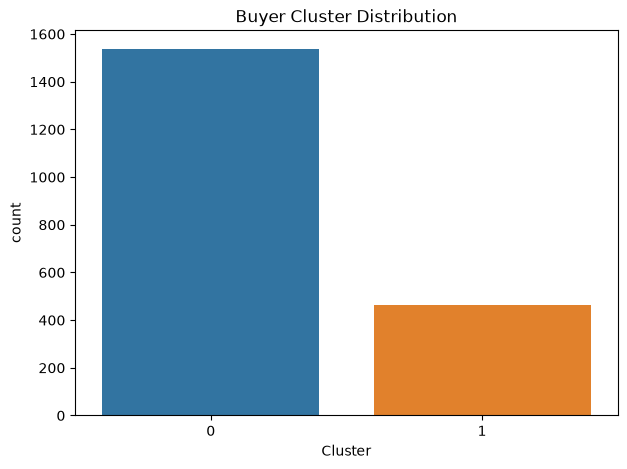

In [29]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=master,
    x="Cluster",
    hue="Cluster",
    legend=False
)

plt.title("Buyer Cluster Distribution")

plt.show()

### Business Insight

This visualization shows how buyers are distributed across the identified customer segments.

In [30]:
cluster_summary = (

    master

    .groupby("Cluster")

    [

        [

            "age",

            "satisfaction_score",

            "total_properties",

            "total_investment",

            "average_sale_price",

            "average_floor_area"

        ]

    ]

    .mean()

)

cluster_summary

,age,satisfaction_score,total_properties,total_investment,average_sale_price,average_floor_area
Cluster,,,,,,
0,56.153446,3.030559,3.677503,1.269852e+06,347459.462809,1148.061645
1,54.380952,3.023810,3.569264,1.228828e+06,345859.865667,1145.542265


In [31]:
cluster_summary.round(2)

,age,satisfaction_score,total_properties,total_investment,average_sale_price,average_floor_area
Cluster,,,,,,
0,56.15,3.03,3.68,1269852.05,347459.46,1148.06
1,54.38,3.02,3.57,1228827.94,345859.87,1145.54


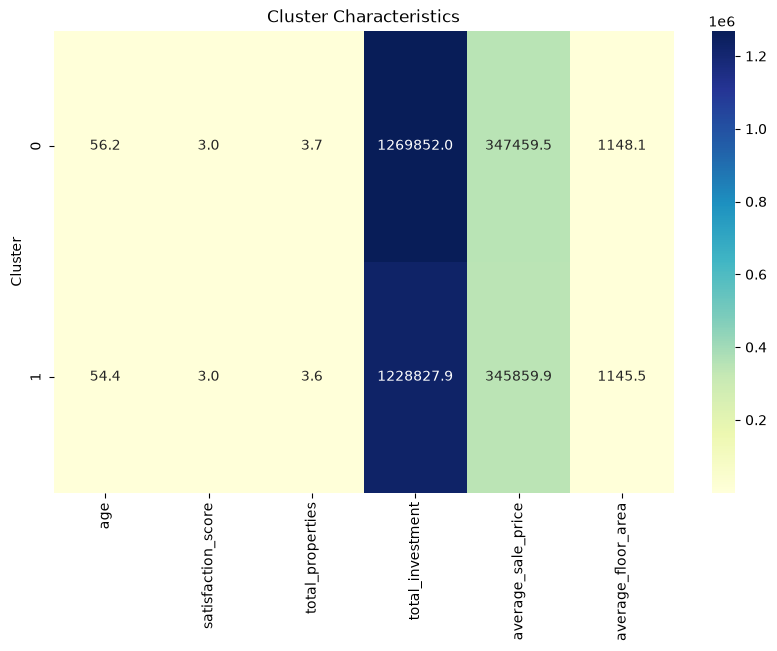

In [32]:
plt.figure(figsize=(10,6))

sns.heatmap(

    cluster_summary,

    annot=True,

    cmap="YlGnBu",

    fmt=".1f"

)

plt.title("Cluster Characteristics")

plt.show()

### Business Insight

The heatmap highlights the behavioral differences among buyer clusters, enabling data-driven customer profiling.

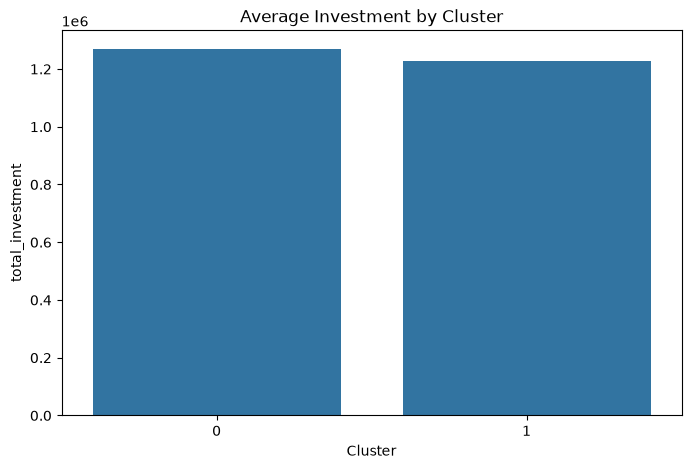

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=master,

    x="Cluster",

    y="total_investment",

    estimator="mean",
    errorbar=None

)

plt.title("Average Investment by Cluster")

plt.show()

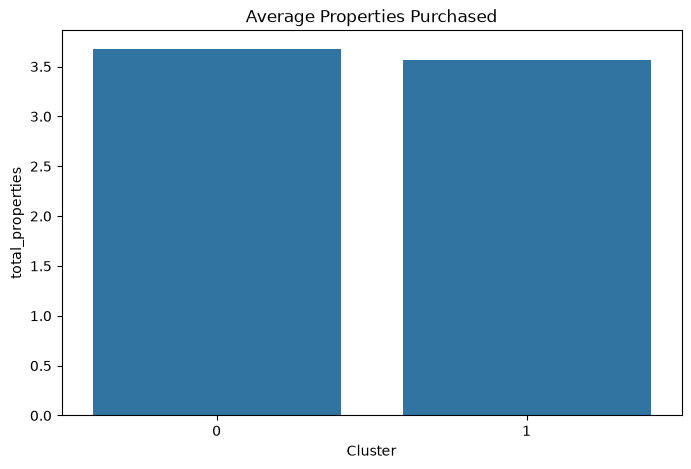

In [34]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=master,

    x="Cluster",

    y="total_properties",

    estimator="mean",
    errorbar=None

)

plt.title("Average Properties Purchased")

plt.show()

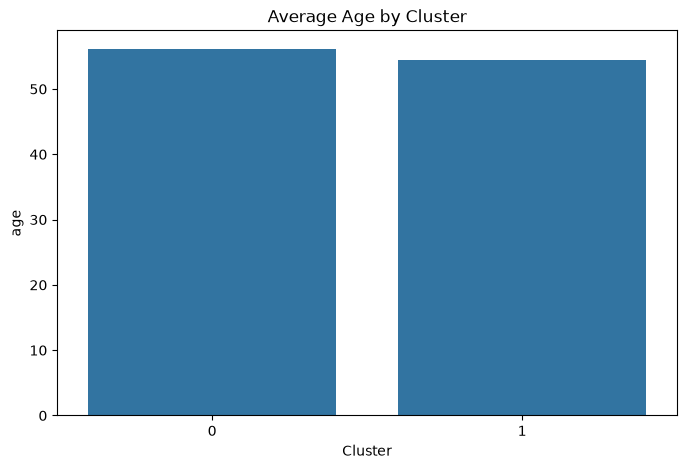

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=master,

    x="Cluster",

    y="age",

    estimator="mean",
    errorbar=None

)

plt.title("Average Age by Cluster")

plt.show()

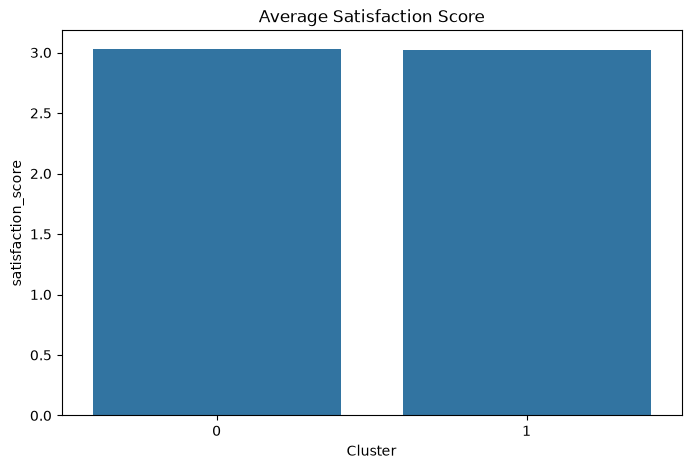

In [36]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=master,

    x="Cluster",

    y="satisfaction_score",

    estimator="mean",
    errorbar=None

)

plt.title("Average Satisfaction Score")

plt.show()

## Part 2 Complete

Completed Tasks

- Optimal cluster selection using Elbow Method
- Cluster validation using Silhouette Score
- K-Means model training
- Buyer cluster creation
- Cluster-level investment analysis

# Hierarchical Clustering & Cluster Visualization

This section validates the K-Means segmentation using Hierarchical Clustering and visualizes buyer clusters in two dimensions using Principal Component Analysis (PCA).

In [37]:
from sklearn.decomposition import PCA

In [38]:
linked = linkage(
    scaled_data,
    method="ward"
)

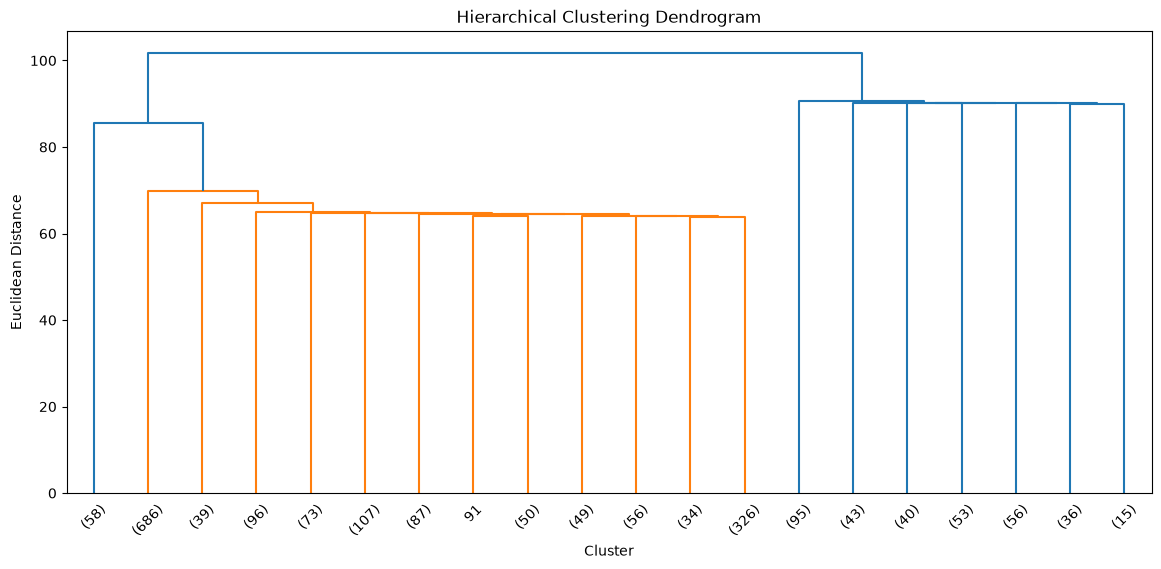

In [39]:
plt.figure(figsize=(14,6))

dendrogram(
    linked,
    truncate_mode="lastp",
    p=20,
    leaf_rotation=45,
    leaf_font_size=10
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster")
plt.ylabel("Euclidean Distance")

plt.show()

### Business Insight

The dendrogram illustrates how buyer groups merge together based on similarity. It helps validate the number of clusters selected through the Elbow Method.

In [40]:
hierarchical = AgglomerativeClustering(
    n_clusters=best_k
)

hier_clusters = hierarchical.fit_predict(
    scaled_data
)

In [41]:
master["Hierarchical_Cluster"] = hier_clusters

In [42]:
master["Hierarchical_Cluster"].value_counts()

Hierarchical_Cluster
1    1662
0     338
Name: count, dtype: int64

In [43]:
pca = PCA(
    n_components=2,
    random_state=42
)

pca_data = pca.fit_transform(
    scaled_data
)

In [44]:
pca_df = pd.DataFrame(
    pca_data,
    columns=[
        "PC1",
        "PC2"
    ]
)

pca_df["Cluster"] = clusters

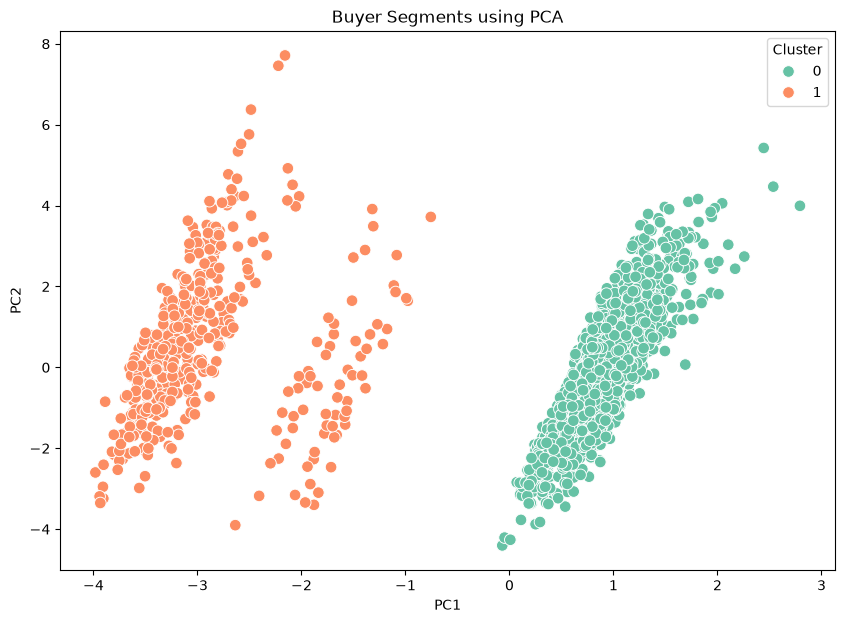

In [45]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=70
)

plt.title("Buyer Segments using PCA")

plt.show()

### Business Insight

PCA reduces multiple variables into two principal components, allowing visual interpretation of buyer segments while preserving most of the data variation.

In [46]:
print(
    pca.explained_variance_ratio_
)

[0.03664497 0.03302334]


In [47]:
print(
    pca.explained_variance_ratio_.sum()
)

0.0696683043992384


### Business Insight

The explained variance indicates how much information from the original dataset is retained after dimensionality reduction.

In [48]:
pd.crosstab(
    master["Cluster"],
    master["client_type"]
)

client_type,Company,Individual
Cluster,,
0,80,1458
1,23,439


In [49]:
pd.crosstab(
    master["Cluster"],
    master["loan_applied"]
)

loan_applied,No,Yes
Cluster,,
0,974,564
1,290,172


In [50]:
pd.crosstab(
    master["Cluster"],
    master["acquisition_purpose"]
)

acquisition_purpose,Home,Investment
Cluster,,
0,1068,470
1,317,145


In [51]:
pd.crosstab(
    master["Cluster"],
    master["region"]
)

region,Alberta,Arizona,Baja California,Bavaria,Berlin,British Columbia,Brittany,Brussels,California,Capital Region,...,Texas,Utah,Victoria,Virginia,Wales,Wallonia,Washington,Western Australia,Wyoming,Zealand
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0,108,0,0,0,0,0,0,633,0,...,56,87,0,65,0,0,73,0,1,0
1,27,0,7,12,11,20,16,12,0,5,...,0,0,13,0,17,15,0,6,0,2


In [52]:
pd.crosstab(
    master["Cluster"],
    master["country"]
)

country,Australia,Belgium,Canada,Denmark,France,Germany,Mexico,Russia,UK,USA
Cluster,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,1538
1,39,43,85,15,53,56,40,36,95,0


## Part 3 Summary

Completed Tasks

- Hierarchical Clustering performed.
- Dendrogram generated.
- PCA visualization completed.
- Buyer clusters validated.
- Cluster demographics explored.

# Cluster Interpretation & Buyer Personas

This section interprets the discovered clusters and assigns meaningful buyer personas based on demographic, financial and investment characteristics.

In [53]:
cluster_profile = (

    master

    .groupby("Cluster")

    .agg({

        "age":"mean",

        "satisfaction_score":"mean",

        "total_properties":"mean",

        "total_investment":"mean",

        "average_sale_price":"mean",

        "average_floor_area":"mean"

    })

    .round(2)

)

cluster_profile

,age,satisfaction_score,total_properties,total_investment,average_sale_price,average_floor_area
Cluster,,,,,,
0,56.15,3.03,3.68,1269852.05,347459.46,1148.06
1,54.38,3.02,3.57,1228827.94,345859.87,1145.54


In [54]:
pd.crosstab(

    master["Cluster"],

    master["client_type"],

    normalize="index"

).round(2)

client_type,Company,Individual
Cluster,,
0,0.05,0.95
1,0.05,0.95


In [55]:
pd.crosstab(

    master["Cluster"],

    master["loan_applied"],

    normalize="index"

).round(2)

loan_applied,No,Yes
Cluster,,
0,0.63,0.37
1,0.63,0.37


In [56]:
pd.crosstab(

    master["Cluster"],

    master["acquisition_purpose"],

    normalize="index"

).round(2)

acquisition_purpose,Home,Investment
Cluster,,
0,0.69,0.31
1,0.69,0.31


## Buyer Persona Assignment

After reviewing the cluster statistics above, assign descriptive names to the clusters.

**Do not fill this mapping yet.** Wait until you inspect the outputs from Cells 53–56.

In [ ]:
cluster_mapping = {
    0: "Cluster 0",
    1: "Cluster 1"
}

In [58]:
master["Buyer_Segment"] = master["Cluster"].map(
    cluster_mapping
)

In [59]:
master["Buyer_Segment"].value_counts()

Buyer_Segment
Cluster 0    1538
Cluster 1     462
Name: count, dtype: int64

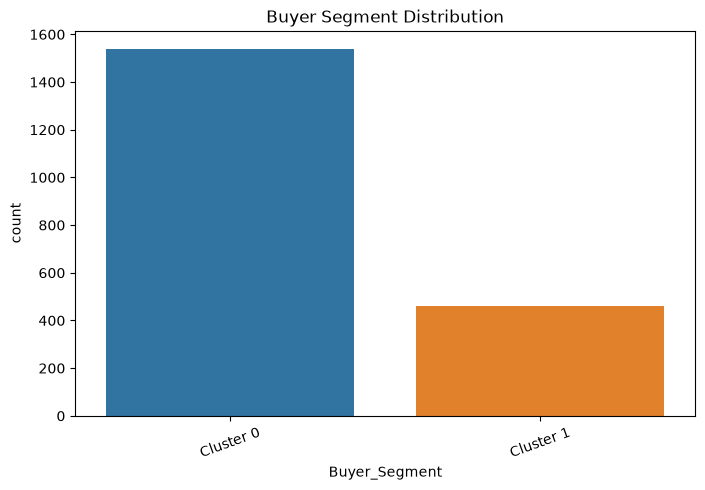

In [60]:
plt.figure(figsize=(8,5))

sns.countplot(

    data=master,

    x="Buyer_Segment",

    hue="Buyer_Segment",

    legend=False

)

plt.title("Buyer Segment Distribution")

plt.xticks(rotation=20)

plt.show()

### Business Insight

Each segment represents a unique buyer profile that can be targeted using personalized marketing campaigns and investment recommendations.

In [61]:
master.to_csv(

    "../data/final_clustered_dataset.csv",

    index=False

)

print("Final clustered dataset saved successfully.")

Final clustered dataset saved successfully.


In [62]:
import joblib

joblib.dump(

    kmeans,

    "../models/kmeans_model.pkl"

)

joblib.dump(

    scaler,

    "../models/scaler.pkl"

)

print("Models saved successfully.")

Models saved successfully.


# Model Building Conclusion

The buyer segmentation model successfully identified distinct customer groups using unsupervised machine learning techniques.

### Techniques Used

- One-Hot Encoding
- StandardScaler
- K-Means Clustering
- Elbow Method
- Silhouette Score
- Hierarchical Clustering
- PCA Visualization

### Deliverables Generated

- Cluster Labels
- Buyer Personas
- Final Clustered Dataset
- Trained K-Means Model
- Scaler Object

These outputs will be used in the Streamlit dashboard to provide interactive buyer segmentation and investment profiling.

In [63]:
master.to_csv(
    "../data/final_clustered_dataset.csv",
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [64]:
cluster_summary.round(2)

,age,satisfaction_score,total_properties,total_investment,average_sale_price,average_floor_area
Cluster,,,,,,
0,56.15,3.03,3.68,1269852.05,347459.46,1148.06
1,54.38,3.02,3.57,1228827.94,345859.87,1145.54
